# YJMob2 disaster mobility: motif diversity and regularity

This notebook analyses the observed disaster/evacuation panel at H3 resolution 8. It omits motif-prevalence plots and describes individual diversity, weekday/weekend regularity, and weekly progression through the observation period.

In [1]:
from pathlib import Path
import sys

import seaborn as sns
from IPython.display import display

PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / 'pyproject.toml').exists()
)
for path in [PROJECT_ROOT, PROJECT_ROOT / 'notebooks']:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from motif_analysis_utils import (
    classify_observed_daily_motifs, motif_diversity_and_regularity, weekly_motif_progression,
    plot_motif_diversity, plot_weekday_weekend_regularity, plot_weekly_progression,
)

sns.set_theme(style='whitegrid', context='notebook')
OBSERVED_PATH = PROJECT_ROOT / 'data' / 'yjmob2' / 'yjmob2_wgs84_simple.parquet'
assert OBSERVED_PATH.exists(), OBSERVED_PATH
print(f'Observed input: {OBSERVED_PATH}')

Observed input: /home/gustavo/citybehavex/data/yjmob2/yjmob2_wgs84_simple.parquet


In [2]:
analysis = classify_observed_daily_motifs(
    OBSERVED_PATH, uid_col='uid', timestamp_col='timestamp', location_col=None,
    lat_col='lat', lng_col='lon', h3_resolution=8,
)
daily = analysis['daily']
display(analysis['coverage'])
print(analysis['purpose_heuristic_warning'])
if not analysis['skipped_user_days'].empty:
    display(analysis['skipped_user_days'])

,metric,value
0,source observations,29389749
1,people,25000
2,input user-days,1774138
3,classified user-days,1708489
4,skipped user-days,65649
5,first date,2019-09-15
6,last date,2019-11-28


yjmob2_wgs84_simple has no explicit purpose column; derived HOME/WORK/OTHER with time-of-day and repeated-location heuristics.


,uid,date
0,10,2019-09-15
1,10,2019-09-16
2,10,2019-09-17
3,10,2019-09-18
4,10,2019-09-19
5,10,2019-09-20
6,10,2019-09-21
7,10,2019-09-22
8,10,2019-09-23
9,10,2019-09-24


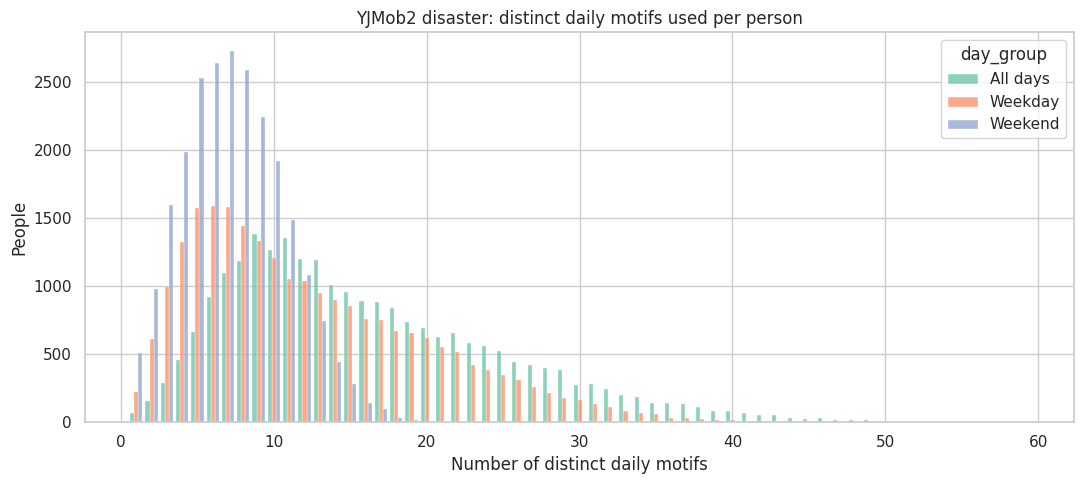

,count,mean,std,min,25%,50%,75%,max
day_group,,,,,,,,
All days,24063.0,16.23,8.98,1.0,9.0,14.0,22.0,59.0
Weekday,24063.0,12.42,7.71,1.0,6.0,11.0,17.0,47.0
Weekend,24063.0,7.37,3.35,1.0,5.0,7.0,10.0,20.0


In [3]:
summaries = motif_diversity_and_regularity(daily)
plot_motif_diversity(summaries['diversity'], 'YJMob2 disaster: distinct daily motifs used per person')
display(summaries['diversity'].groupby('day_group', observed=True)['distinct_motifs'].describe().round(2))

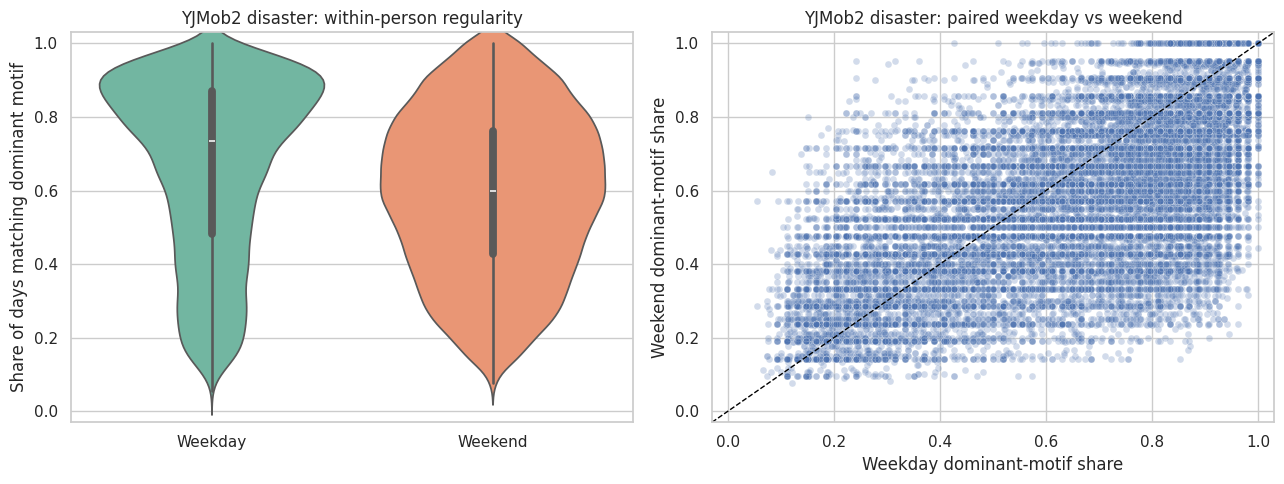

People eligible for paired comparison: 24,063
Mean weekday regularity: 66.5%
Mean weekend regularity: 58.9%
Mean weekend minus weekday difference: -7.6%


In [4]:
plot_weekday_weekend_regularity(
    summaries['regularity_long'], summaries['paired_regularity'], 'YJMob2 disaster'
)
paired = summaries['paired_regularity']
print(f'People eligible for paired comparison: {len(paired):,}')
print(f'Mean weekday regularity: {paired["Weekday"].mean():.1%}')
print(f'Mean weekend regularity: {paired["Weekend"].mean():.1%}')
print(f'Mean weekend minus weekday difference: {(paired["Weekend"] - paired["Weekday"]).mean():+.1%}')

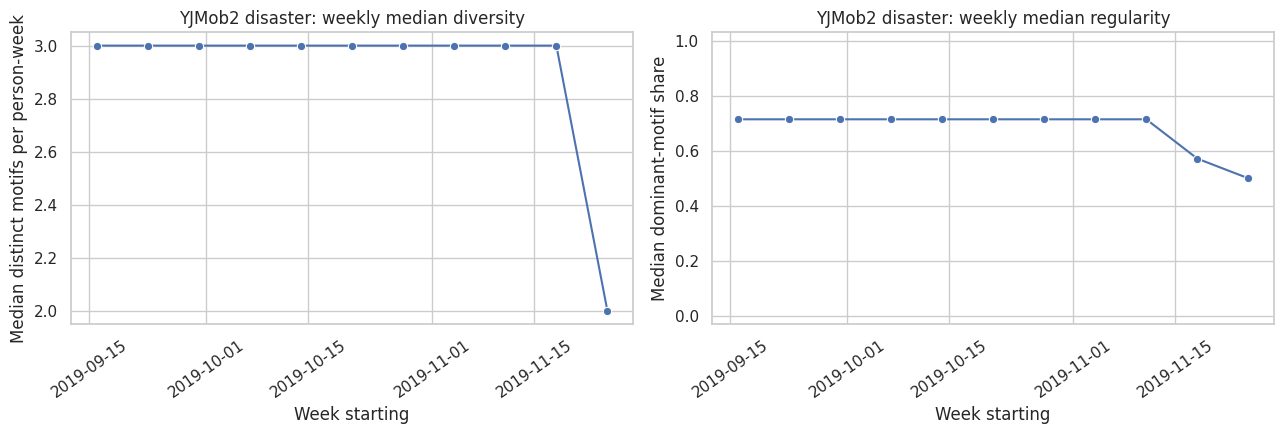

,week_start,median_distinct_motifs,diversity_people,median_regularity,regularity_people
0,2019-09-16,3.0,23191,0.714286,23042
1,2019-09-23,3.0,23422,0.714286,23328
2,2019-09-30,3.0,23582,0.714286,23502
3,2019-10-07,3.0,23778,0.714286,23670
4,2019-10-14,3.0,23831,0.714286,23757
5,2019-10-21,3.0,23788,0.714286,23712
6,2019-10-28,3.0,23504,0.714286,23377
7,2019-11-04,3.0,23366,0.714286,23238
8,2019-11-11,3.0,24056,0.714286,24047
9,2019-11-18,3.0,24061,0.571429,24053


In [5]:
weekly = weekly_motif_progression(daily)
assert not weekly.empty, 'No eligible person-weeks for the disaster progression.'
plot_weekly_progression(weekly, 'YJMob2 disaster')
display(weekly)

## Reading the results

Locations are discretized at H3 resolution 8. The common figures describe the diversity of daily graph structures and whether people repeat a dominant structure on weekdays or weekends. The weekly progression reports medians across people: regularity includes only person-weeks with at least two observed days. The time series is descriptive and does not make a causal pre/post-disaster claim.